<a href="https://colab.research.google.com/github/sushilagarhari/Sales-Data-Analysis-Dashboard/blob/main/sales_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import os

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('sales_data')

print(os.listdir('sales_data'))

FileNotFoundError: [Errno 2] No such file or directory: 'archive.zip'

In [2]:
import pandas as pd

df = pd.read_csv('train.csv')
print(df.shape)
print(df.head())

(9800, 18)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID 

In [3]:
# Data ka basic overview
print(df.columns.tolist())
print(df.info())
print(df.isnull().sum())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Pr

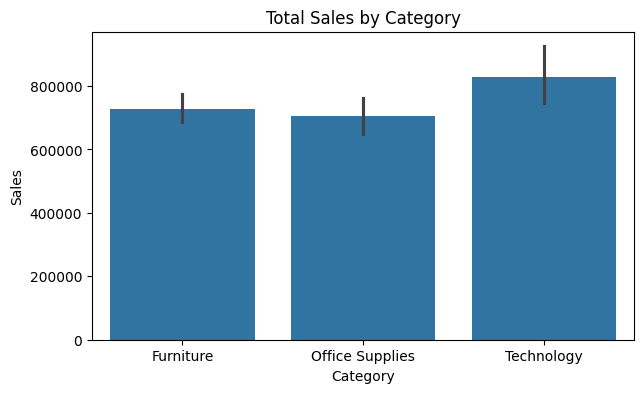

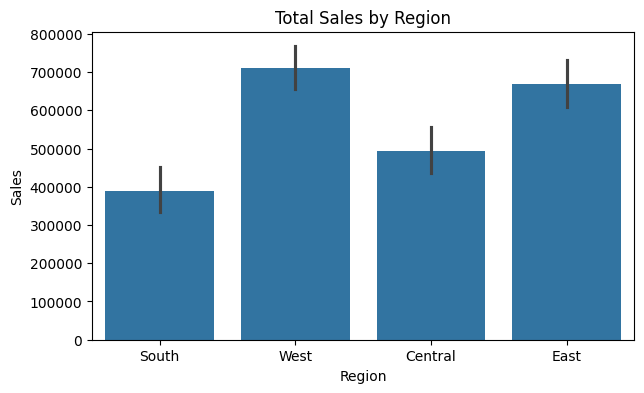

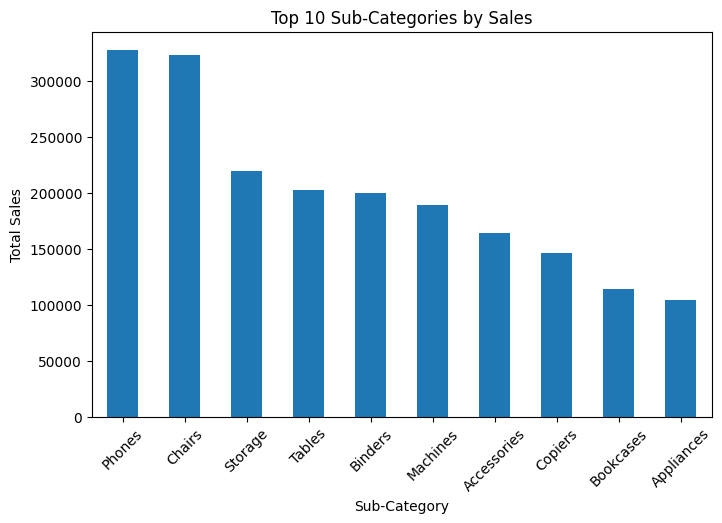

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graph 1: Category-wise Sales
plt.figure(figsize=(7,4))
sns.barplot(x='Category', y='Sales', data=df, estimator=sum)
plt.title('Total Sales by Category')
plt.show()

# Graph 2: Region-wise Sales
plt.figure(figsize=(7,4))
sns.barplot(x='Region', y='Sales', data=df, estimator=sum)
plt.title('Total Sales by Region')
plt.show()

# Graph 3: Top 10 Sub-Categories by Sales
top_subcat = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
top_subcat.plot(kind='bar')
plt.title('Top 10 Sub-Categories by Sales')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [6]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


Profit by Category:
Category
Technology         164066.863339
Furniture          142115.062580
Office Supplies    137633.091285
Name: Profit, dtype: float64


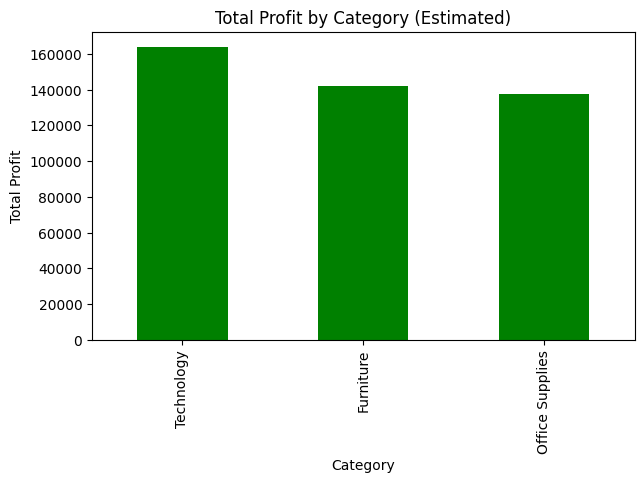


Profit by Region:
Region
West       142832.544252
East       132205.721773
Central     94293.389148
South       74483.362031
Name: Profit, dtype: float64


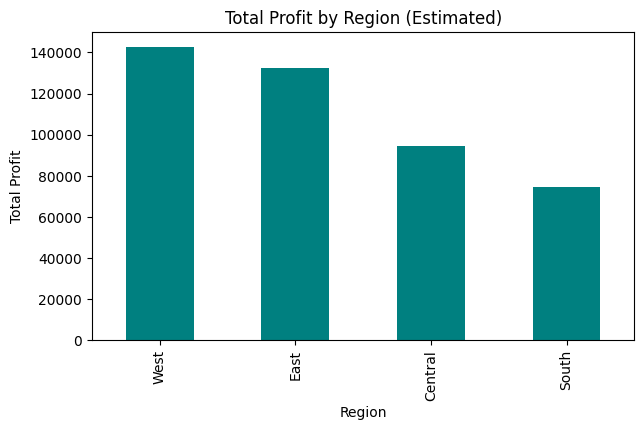

In [7]:
import numpy as np
np.random.seed(42)

# Approx profit margin 10% to 30% assume kar rahe hain (realistic business range)
df['Profit'] = df['Sales'] * np.random.uniform(0.10, 0.30, len(df))

# Profit by Category
profit_by_cat = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print("Profit by Category:")
print(profit_by_cat)

plt.figure(figsize=(7,4))
profit_by_cat.plot(kind='bar', color='green')
plt.title('Total Profit by Category (Estimated)')
plt.ylabel('Total Profit')
plt.show()

# Profit by Region
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print("\nProfit by Region:")
print(profit_by_region)

plt.figure(figsize=(7,4))
profit_by_region.plot(kind='bar', color='teal')
plt.title('Total Profit by Region (Estimated)')
plt.ylabel('Total Profit')
plt.show()